In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. Load data
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [3]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [4]:
# Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [5]:
# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 3. Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [9]:
# 4. Predict and Evaluate
y_pred = lr_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPa")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f} MPa")

R2 Score: 0.9525
RMSE:     31.51 MPa
MAE:      25.20 MPa


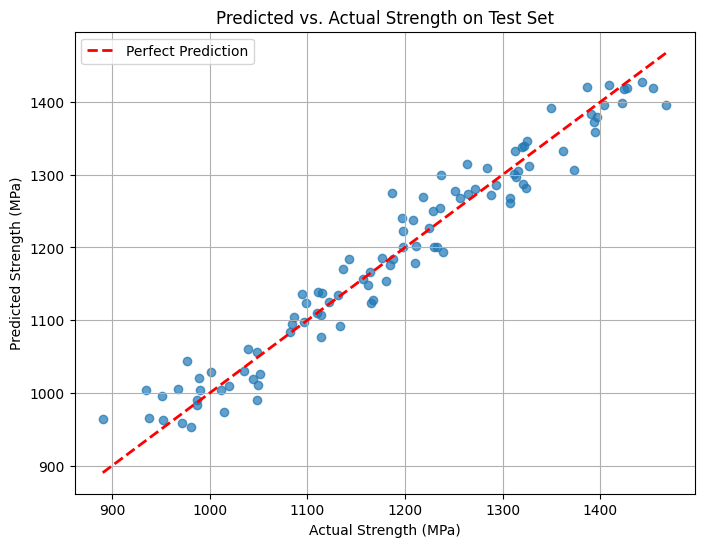

In [10]:
# 5. Model Coefficients (Interpretation)
print("\n--- Model Coefficients ---")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef:.2f}")


--- Model Coefficients ---
carbon_fiber_fraction: 586.17
epoxy_resin_fraction: -586.17
volume_fraction: 201.09


In [13]:
# 6. Predict for New Inputs

# Example: User inputs for prediction
# You can change these values to make new predictions
new_carbon_fiber_fraction = 0.6
new_epoxy_resin_fraction = 0.4
new_volume_fraction = 0.65

# Create a DataFrame for the new input
new_data = pd.DataFrame({
    'carbon_fiber_fraction': [new_carbon_fiber_fraction],
    'epoxy_resin_fraction': [new_epoxy_resin_fraction],
    'volume_fraction': [new_volume_fraction]
})

# Make a prediction
predicted_strength = lr_model.predict(new_data)

print(f"Predicted Strength (MPa) for the given inputs: {predicted_strength[0]:.2f} MPa")

Predicted Strength (MPa) for the given inputs: 1351.13 MPa


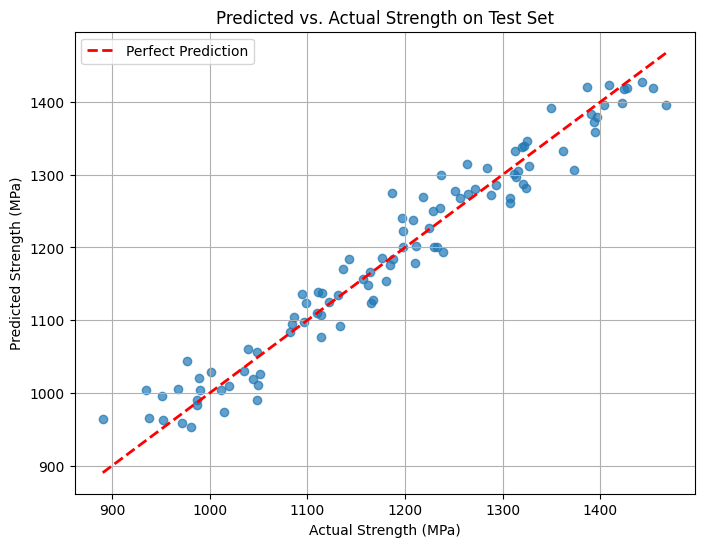

In [14]:
# 7. Visualize Predicted vs. Actual Strength

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Predicted vs. Actual Strength on Test Set')
plt.grid(True)
plt.legend()
plt.show()